In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
import os
import sys

import numpy as np 
import torch

import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor, RichProgressBar, RichModelSummary, DeviceStatsMonitor
from lightning.pytorch.loggers import WandbLogger

from box import Box
import yaml

from pathlib import Path
import time 

import tqdm

In [85]:
BASE_DIR = Path.cwd().parent
VERSION = 1

# -- for colab traning
# BASE_DIR = '/content/drive/MyDrive/SonarOdometry'
# from google.colab import drive
# drive.mount('/content/drive')


if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

print(f'Setting root dir to: {BASE_DIR}')

# --- if colab
# copy traning data to
# !cp /content/drive/MyDrive/SonarOdometry/data/dataset.zip /content/
# !unzip -q /content/dataset.zip -d /content/dataset/
# data_dir = '/content/dataset/'


# import modules
from src.models.dpso_train import DPSO_train as DPSO
from src.data_loader.lightning_module import DPSO_LightningModule
from src.data_loader.data_module_lightning import SonarSimDataModule
from src.data_loader.transforms import SonarDatasetTranforms


# model configuration files
model_config_pth = os.path.join(BASE_DIR, 'config', 'model.yaml')
sonar_config_pth = os.path.join(BASE_DIR, 'config', 'sonar.yaml')

# dataset path
data_dir = os.path.join(BASE_DIR, 'SonarOdometryDataset')

# output data 
output_dir = os.path.join(BASE_DIR, f'training/output/test_{VERSION}') 
os.makedirs(output_dir, exist_ok=True)

print(f'Training results directory: {output_dir}')

Setting root dir to: c:\Users\janis\Projekty\Magisterka\SonarOdometry
Training results directory: c:\Users\janis\Projekty\Magisterka\SonarOdometry\training/output/test_1


In [86]:
# === DATASET CONFIGURATION ===
with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

fls_img_size = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH)
transforms = SonarDatasetTranforms

In [87]:
# === TEST CONFIGURATION ===
init_frames = model_config.INIT_FRAMES # init_frames < frames_in_series
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

frames_in_series = 12

dm = SonarSimDataModule(os.path.join(data_dir, 'supervised'), 1, 1, 0, transforms, frames_in_series)
dm.setup(stage = 'fit')
test_dataloader = dm.train_dataloader()
print(len(test_dataloader))

12060


In [88]:
ckpt_path ="C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/output/test_1/model.ckpt" 
lightning_model = DPSO_LightningModule.load_from_checkpoint(ckpt_path, weights_only=False)
dpso = lightning_model.model
dpso.eval()

c:\Users\janis\miniconda3\envs\so\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


DPSO_train(
  (PatchGraph): Graph(
    (patchifier): Patchifier(
      (feature_extractor): Encoder(
        (conv1): Conv2d(1, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (ResBlock1): Sequential(
          (0): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (norm2): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          )
          (1): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3

In [ ]:



num = 2

gt = []
pred = []

with torch.no_grad():
    for _ in range(num):
        fls_series, time, trajectory_gt, depth_gt = next(iter(test_dataloader))
        
        print(f'Evaluating samples: {time.shape[1]}.')
        
        output = dpso(frames=fls_series, 
                            timestamp=time, 
                            poses_gt=trajectory_gt, 
                            depth_gt=depth_gt, 
                            supervised=True, 
                            freeze_poses=False, 
                            init_poses_noise=0.0, 
                            debug_logger=False)
        
        pred_poses, target_projection, predicted_projection, valid_mask, weights, delta = output[-1]
        
        print(f"Średnia waga ufności sieci: {weights.mean().item():.4f}")
        print(f"Odchylenie standardowe wag: {weights.std().item():.4f}")

        
        trajectory_gt_sonar = dpso.calib.pose(trajectory_gt)
        gt.append(trajectory_gt_sonar)
        pred.append(pred_poses)
        

Evaluating samples: 12.
Średnia waga ufności sieci: 0.3239
Odchylenie standardowe wag: 0.4680
Evaluating samples: 12.
Średnia waga ufności sieci: 0.4474
Odchylenie standardowe wag: 0.4972


Starting pts
gt: [ 185.8469   -149.73311    14.846534] pred: [ 185.8469   -149.73311    14.846534]
Metrcis:
> ATE: 0.36965131759643555
> RPE: 0.13780034758339282


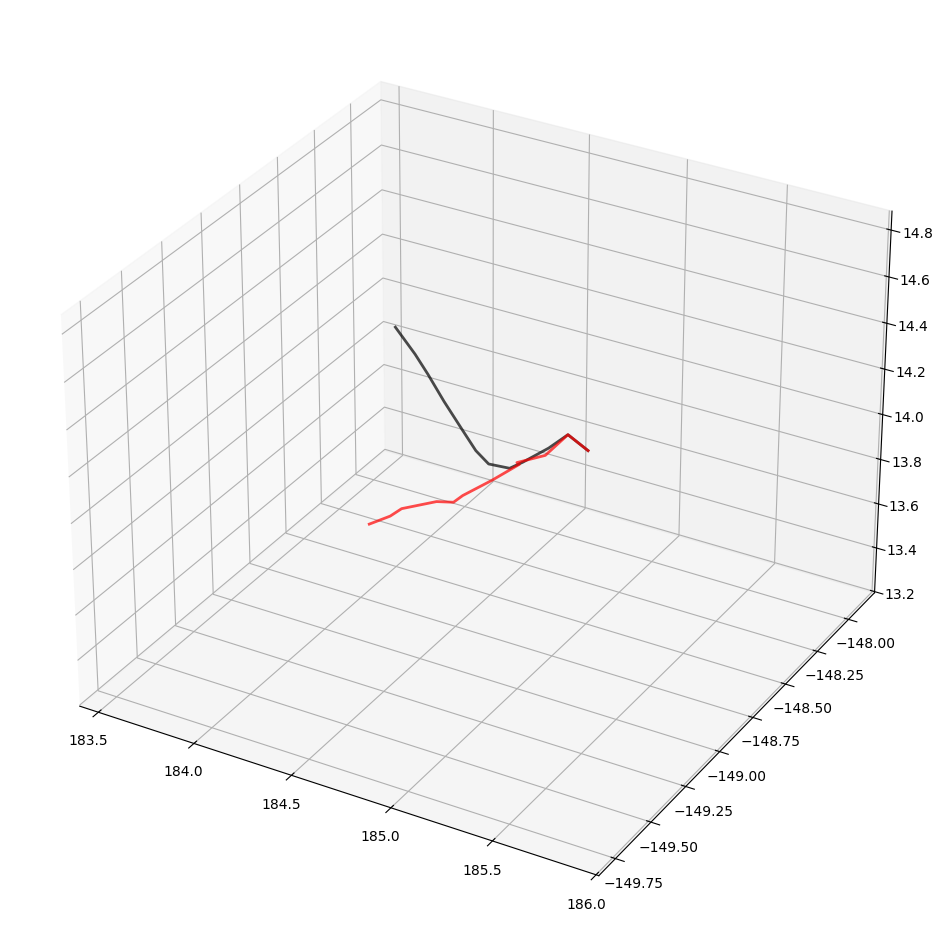

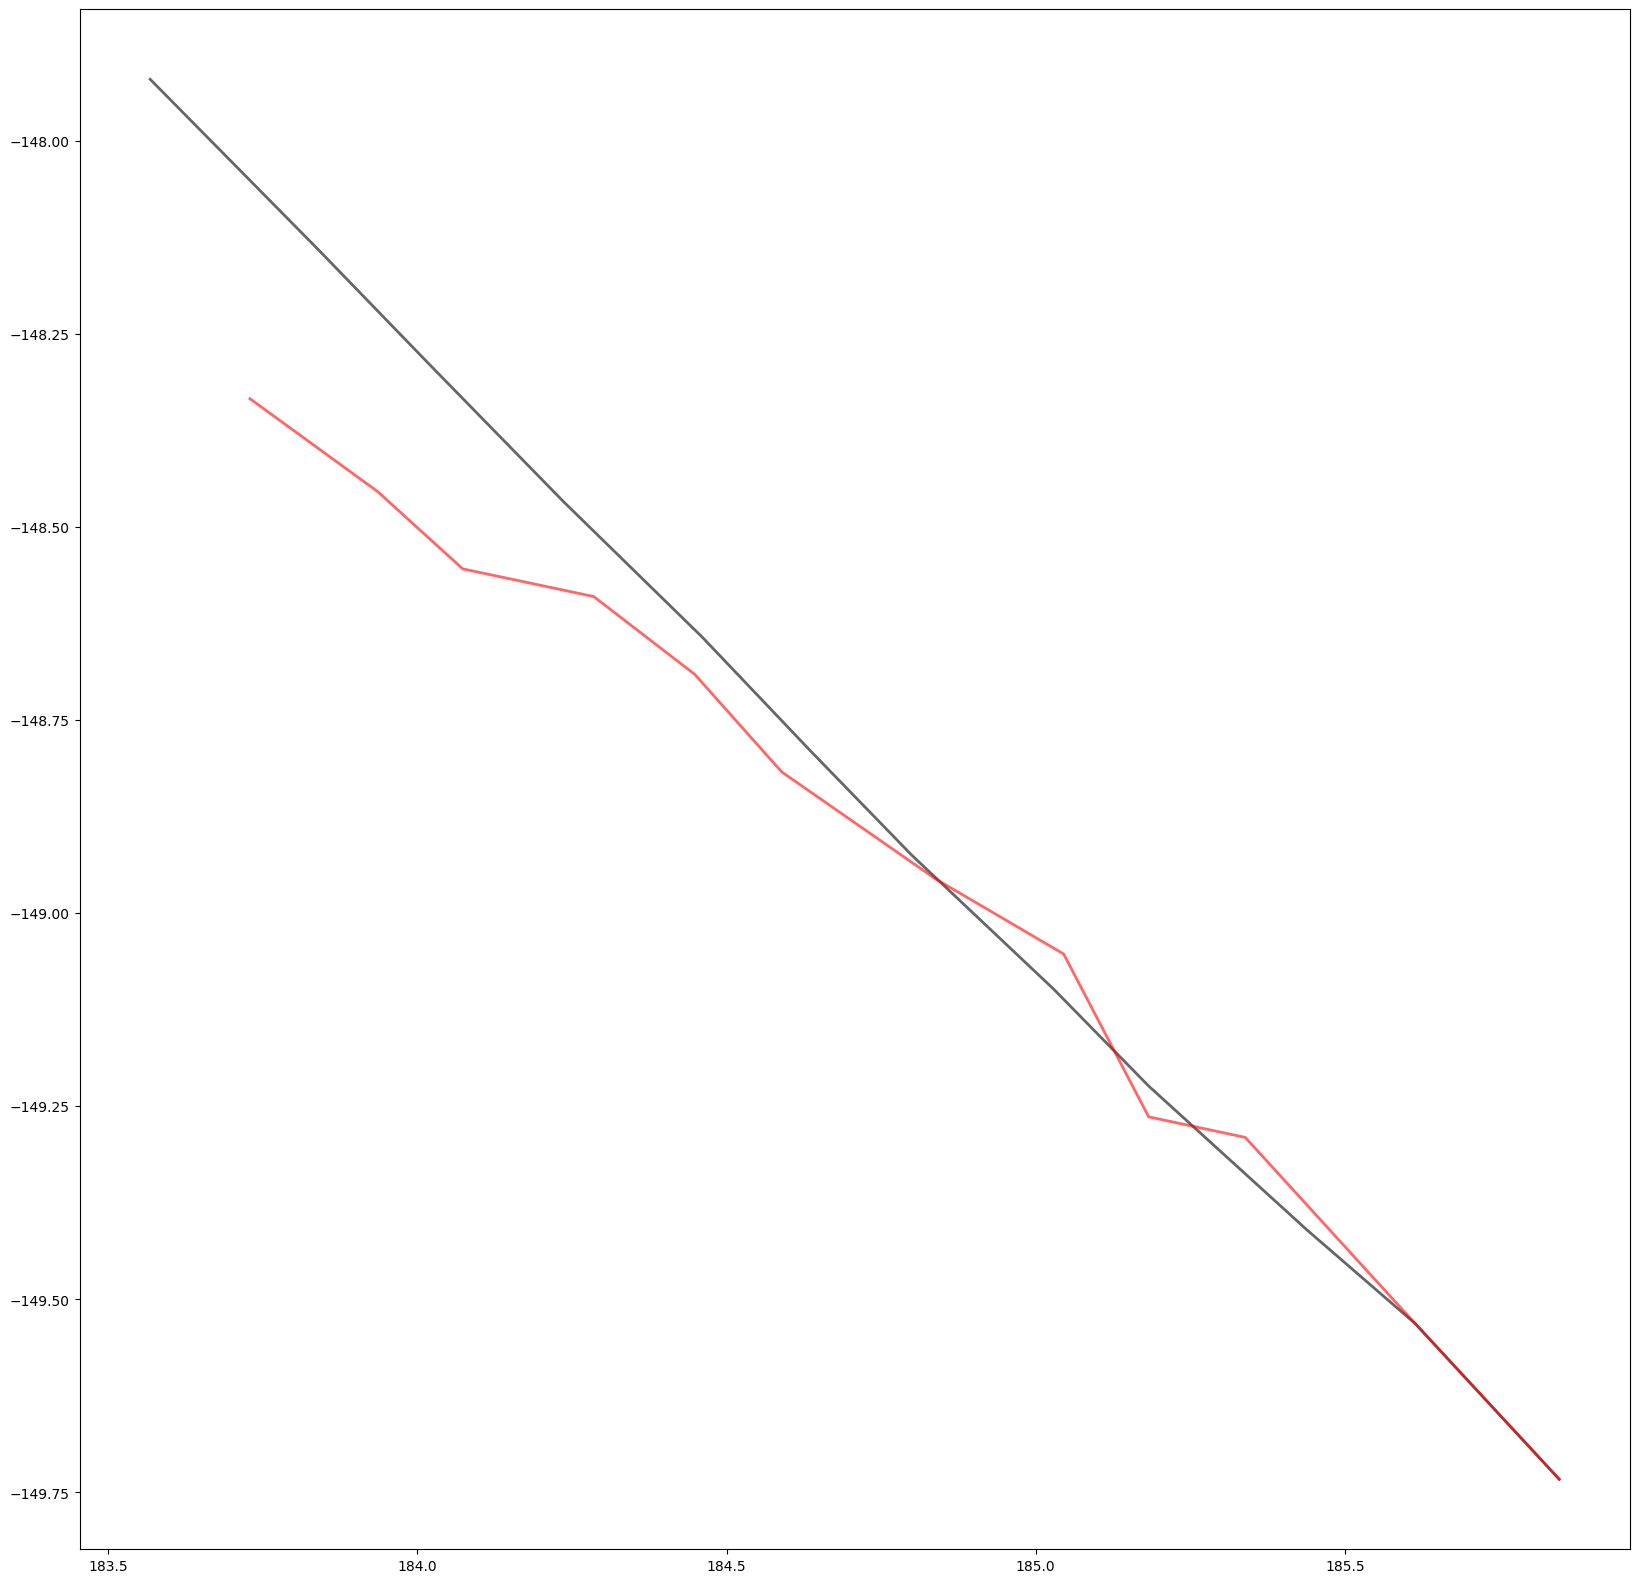

Starting pts
gt: [-66.31502  -38.871883  18.431423] pred: [-66.31502  -38.871883  18.431423]
Metrcis:
> ATE: 0.4161582291126251
> RPE: 0.15473916735476098


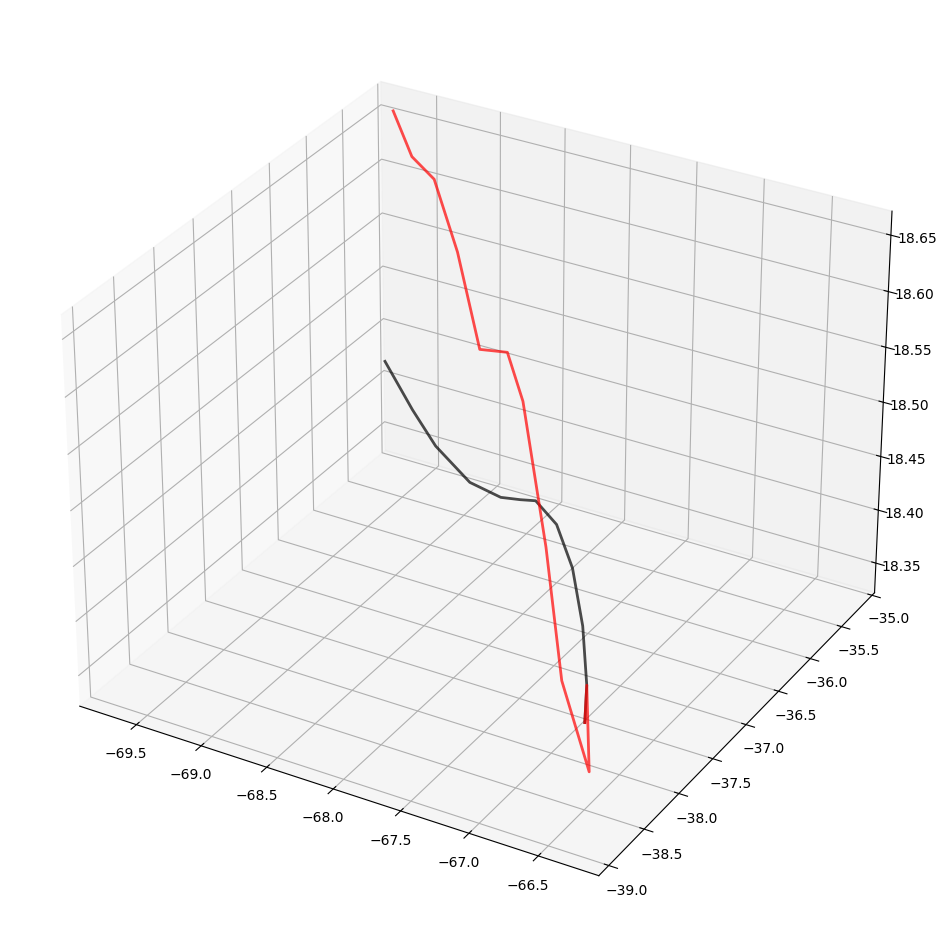

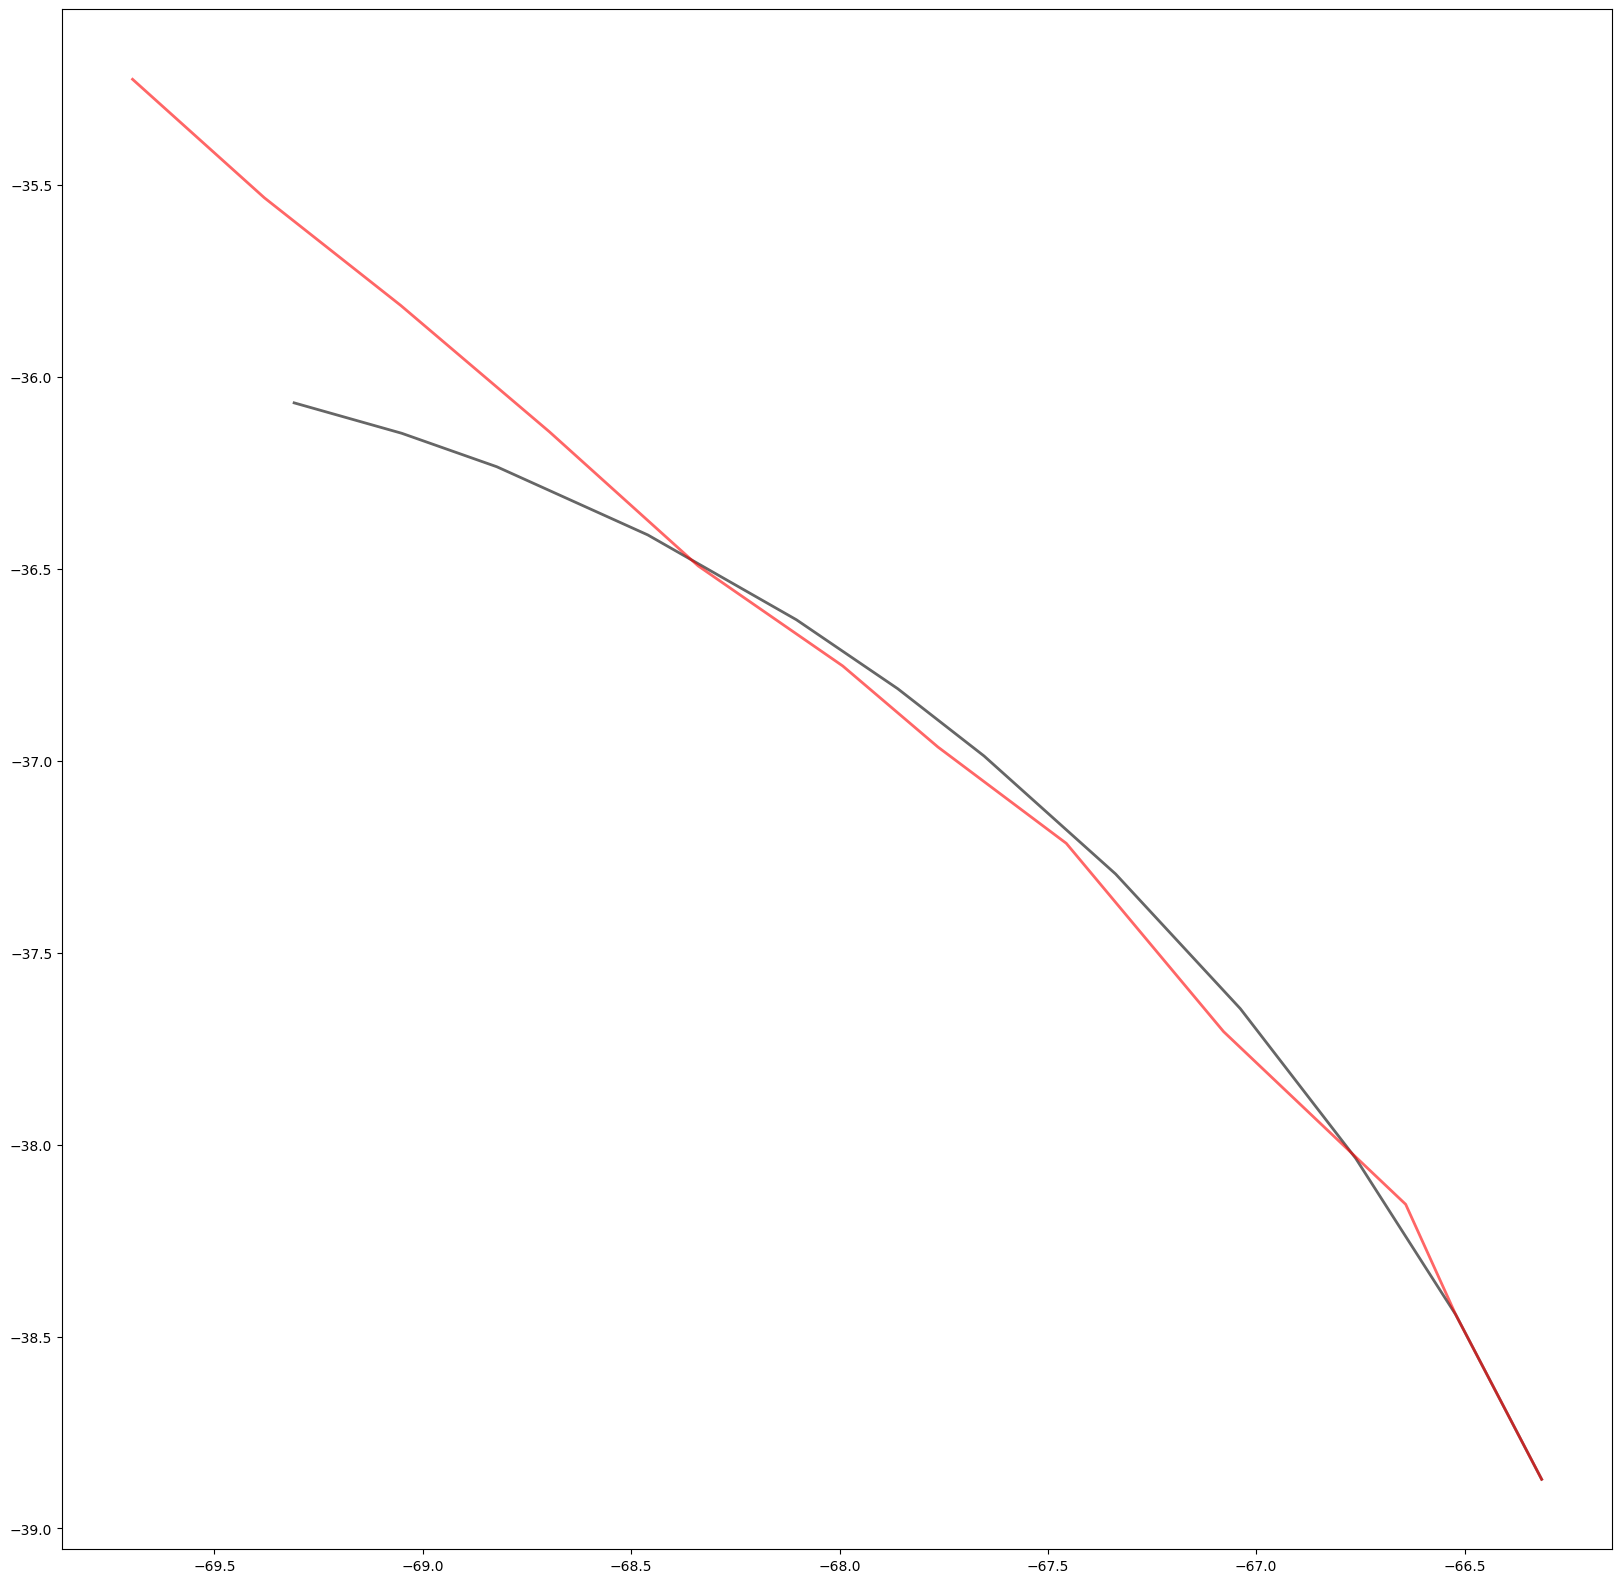

In [90]:
import matplotlib.pyplot as plt 
from src.data_loader.metrics import eval_metrics

for i in range(num):

    batch_gt = gt[i]
    batch_pred = pred[i]

    gt_coods = batch_gt[0, :, :3].detach().cpu().numpy()
    pred_coods = batch_pred[0, :, :3].detach().cpu().numpy()

    print(f'Starting pts\ngt: {gt_coods[0, :]} pred: {pred_coods[0, :]}')

    metrcis = eval_metrics(batch_pred.detach().cpu().numpy(), batch_gt.detach().cpu().numpy(), align=False, align_init_pt_only=False, add_data_series=False)

    print(f"Metrcis:\n> ATE: {metrcis['RMSE_ATE']}\n> RPE: {metrcis['RMSE_RPE']}")


    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(gt_coods[:,0], gt_coods[:,1], gt_coods[:,2], color='black', label='Ground Truth', linewidth=2,  alpha=0.7)
    ax.plot(pred_coods[:,0], pred_coods[:,1], pred_coods[:,2], color='red', label='Prediction', linewidth=2,  alpha=0.7)
                

    plt.show()


    fig, ax = plt.subplots(figsize=(20, 20))
    ax.plot(gt_coods[:,0], gt_coods[:,1], color='black', linewidth=2, alpha=0.6, label='Ground Truth')
    ax.plot(pred_coods[:,0], pred_coods[:,1], color='red', linewidth=2, alpha=0.6, label='Pred')    

    plt.show()
